# QDock-Kaiwu — docking on the Coherent Ising Machine

Molecular docking splits into **pose sampling** (search the binding geometry —
NP-hard) and **scoring** (rank poses — cheap). QDock casts the sampling step as a
**QUBO** and solves it on the **Kaiwu SDK** — the classical simulated annealer and
the real **Coherent Ising Machine (CIM)**. AutoDock Vina scores the poses.

The CIM is an **8-bit** machine, so a QUBO reaches it through a
`PrecisionReducer` that quantizes the matrix; `truncated_precision = t` keeps
`t` bits of each coefficient by splitting a variable across several spins. This
workshop's result: **as you spend more precision `t`, the CIM docks better** —
shown on two redocking cases, one per encoding, each kept under the machine's
1000-spin budget.

| demo | encoding | ligand | qubits → spins @t12 | CIM best RMSD |
|---|---|---|---|---|
| **3f3d** | GPM (grid) | small fragment | 214 → 620 | **1.25 Å** |
| **3d4z** | FAM (features) | gluco-imidazole | 336 → 920 | **1.65 Å** |

## 0. Setup

Get a free `user_id` / `sdk_code` from [platform.qboson.com](https://platform.qboson.com)
and export them as `KAIWU_USER_ID` / `KAIWU_SDK_CODE` before launching Jupyter.

In [1]:
import os, sys, itertools, numpy as np, matplotlib.pyplot as plt
%matplotlib inline
os.environ['PATH'] = os.path.expanduser('~/miniforge3/envs/chem/bin') + os.pathsep + os.environ['PATH']
sys.path.insert(0, os.path.abspath('..'))
import kaiwu as kw
from qdock_kaiwu import GPMDock, FAMDock, backends, scoring, evaluate, viz, init_license
from qdock_kaiwu.qubo import build_gpm_qubo, build_fam_qubo, EN
from qdock_kaiwu.gpm import _matches_to_poses
from qdock_kaiwu.params import GPM as GPM_P, FAM as FAM_P

init_license()                                   # reads KAIWU_USER_ID / KAIWU_SDK_CODE
kw.common.CheckpointManager.save_dir = os.path.abspath('../cim_cache')  # reproduces shipped CIM runs
DATA = os.path.abspath('../data')

## 1. A QUBO on Kaiwu — SA and the real CIM

Kaiwu minimizes an **Ising** Hamiltonian and returns **spin** (±1) reads. Convert
QUBO↔Ising with Kaiwu's own routine and map the ancilla-gauged spins back to
binary. **Feed the converter's output straight to `solve` — no manual sign flip:**
Kaiwu's raw `solve` maximizes `sᵀMs`, but `qubo_matrix_to_ising_matrix` bakes in
the sign so the maximizer minimizes the QUBO.

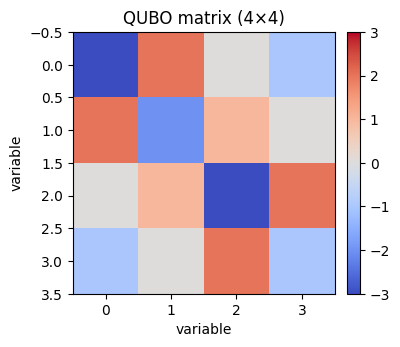

brute-force minimum: -6.0


In [2]:
Q = np.array([[-3.,  2.,  0., -1.],
              [ 0., -2.,  1.,  0.],
              [ 0.,  0., -3.,  2.],
              [ 0.,  0.,  0., -1.]])
brute = min(backends.qubo_energy(Q, np.array(b)) for b in itertools.product([0,1], repeat=4))
fig, ax = plt.subplots(figsize=(4, 3.4)); viz.plot_qubo_matrix(ax, Q); plt.show()
print('brute-force minimum:', brute)

**SA** — `kaiwu.classical.SimulatedAnnealingOptimizer`:

In [3]:
ising, offset = kw.conversion.qubo_matrix_to_ising_matrix(Q)
sa = kw.classical.SimulatedAnnealingOptimizer(initial_temperature=5, alpha=0.99,
         cutoff_temperature=0.01, iterations_per_t=200, size_limit=50, rand_seed=42)
spins = sa.solve(ising)                                  # (reads, n+1) of ±1
ranked = backends._rank_unique([backends._spins_to_binary(s, 4) for s in spins], Q)
print('SA minimum:', ranked[0][0], 'at', ranked[0][1], '| matches brute force:', abs(ranked[0][0]-brute) < 1e-9)

SA minimum: -6.0 at [1 0 1 1] | matches brute force: True


**CIM** — the same Ising matrix on the photonic machine
(`kaiwu.cim.CIMOptimizer`). A submission takes ~1 minute and uses quota; the
shipped cache returns it instantly.

In [4]:
cim = kw.cim.CIMOptimizer(task_name='qdock_workshop_demo', wait=True,
                          interval=1, task_mode='quota', sample_number=10)
spins_cim = np.asarray(cim.solve(ising))
ranked_cim = backends._rank_unique([backends._spins_to_binary(s, 4) for s in spins_cim], Q)
print('CIM minimum:', ranked_cim[0][0], 'at', ranked_cim[0][1], '| matches brute force:', abs(ranked_cim[0][0]-brute) < 1e-9)

[2026-06-23 02:42:38] [INFO    ] [kaiwu.cim._optimizer_adapter:3] - Task calculation successful!, Task name: qdock_workshop_demo


CIM minimum: -6.0 at [1 0 1 0] | matches brute force: True


## 2. Docking as a QUBO

One binary variable per candidate match `x_(a,s) = 1` ⇔ *ligand atom a sits at
site s*. The Hamiltonian rewards a chemically good placement (linear term),
penalizes matches that distort the rigid ligand (`K_dist`), and forbids one atom
in two sites (`K_mono`). Minimizing it selects a consistent set of matches;
superposing matched atoms onto their sites gives a 3-D pose. Two encodings differ
only in what the **sites** are:

- **GPM** — a grid filling the pocket (2.0 Å); reward = van der Waals energy (AutoGrid).
- **FAM** — a few typed pocket **feature atoms** (1.0 Å); reward = electronegativity match.

The CIM solve is the same three lines every time, so we wrap it once:

In [5]:
def cim_dock(Q, task_name, t, samples=300):
    """Solve a docking QUBO on the CIM at precision=8, truncated_precision=t."""
    ising, _ = kw.conversion.qubo_matrix_to_ising_matrix(Q)
    cim = kw.cim.CIMOptimizer(task_name=task_name, wait=True, interval=1,
                              task_mode='quota', sample_number=samples)
    reducer = kw.cim.PrecisionReducer(cim, precision=8, truncated_precision=t,
                                      only_feasible_solution=False)
    spins = np.asarray(reducer.solve(ising))            # quantize → submit → decode
    return backends._rank_unique([backends._spins_to_binary(s, Q.shape[0]) for s in spins], Q)

## 3. GPM demo — 3f3d, sweeping precision on the CIM

Fill the pocket with a 2.0 Å grid; AutoGrid gives each point a van der Waals
energy. 214 variables — small, so even at `t=12` the precision-expanded matrix
stays under the 1000-spin budget.

In [6]:
g = GPMDock(backend='cim', workdir='nb_gpm')
g.make_receptor(f'{DATA}/3f3d_protein.mol2')
g.make_ligand([f'{DATA}/3f3d_ligand.mol2'])
g.make_box_ligand(f'{DATA}/3f3d_ligand.mol2')          # 2.0 Å grid (GPM default)
lig = g.ligands[0]
Qg, vars_g = build_gpm_qubo(lig.coords, lig.ad_types, g.grid_dict, g.box_coords,
                            GPM_P['edge_cutoff'], GPM_P['K_dist'], GPM_P['K_mono'])
print('GPM QUBO variables:', Qg.shape[0])

GPM QUBO variables: 214


Favourable grid points (blue) around the ligand (black):

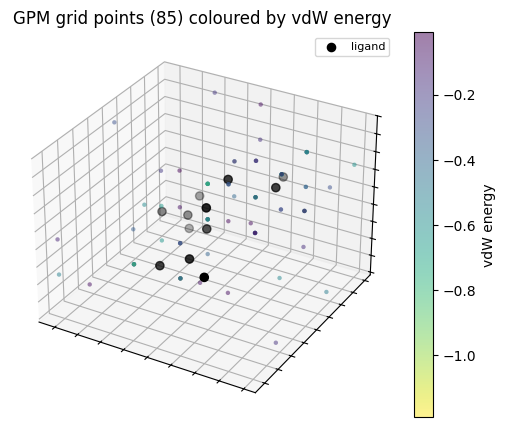

In [7]:
gpts = np.vstack([g.box_coords[g.grid_dict[t][0]] for t in g.grid_dict if len(g.grid_dict[t][0])])
gen  = np.concatenate([g.grid_dict[t][1] for t in g.grid_dict if len(g.grid_dict[t][0])])
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_grid_sites(ax, gpts, gen, lig.coords); plt.show()

**Sweep `truncated_precision` 8 → 10 → 12 on the CIM.** More precision keeps more
of the vdW reward, so the machine resolves the native pose:

In [8]:
sweep = {}
for t in (8, 10, 12):
    ranked = cim_dock(Qg, f'qdock_3f3d_GPM_2p0_p8t{t}', t)
    poses, energies = _matches_to_poses(lig, np.array(vars_g), g.box_coords, ranked)
    P, energies = np.array(poses), np.array(energies)
    rmsd = evaluate.pose_rmsds(P, lig.coords, lig.elements)
    vina = scoring.score_poses(g.receptor_pdbqt, lig.lines, P, 'nb_gpm/score')
    bi = int(np.nanargmin(vina))
    sweep[t] = (rmsd, energies, vina, P, bi)
    print(f't={t:2d}  poses={len(P)}  mRMSD={rmsd.min():.2f}  vina-best RMSD={rmsd[bi]:.2f} Å')

[2026-06-23 02:42:38] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3f3d_GPM_2p0_p8t8


t= 8  poses=7  mRMSD=2.87  vina-best RMSD=4.19 Å
[2026-06-23 02:42:41] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3f3d_GPM_2p0_p8t10


t=10  poses=7  mRMSD=2.89  vina-best RMSD=4.15 Å
[2026-06-23 02:42:44] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3f3d_GPM_2p0_p8t12


t=12  poses=6  mRMSD=1.25  vina-best RMSD=1.25 Å


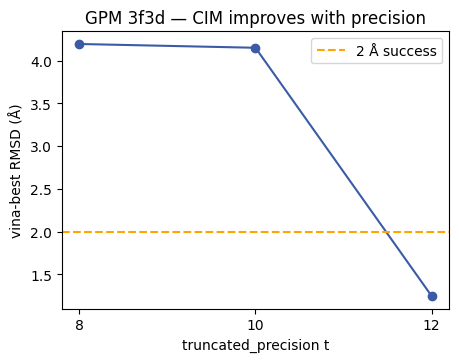

In [9]:
ts = sorted(sweep); best = [sweep[t][0][sweep[t][4]] for t in ts]
fig, ax = plt.subplots(figsize=(5, 3.6))
ax.plot(ts, best, 'o-', color='#3B5BA5'); ax.axhline(2.0, ls='--', color='orange', label='2 Å success')
ax.set_xlabel('truncated_precision t'); ax.set_ylabel('vina-best RMSD (Å)')
ax.set_title('GPM 3f3d — CIM improves with precision'); ax.set_xticks(ts); ax.legend(); plt.show()

The best run (t=12) docks to **1.25 Å**. Overlay it on the crystal and score with Vina:

/Users/songxinwei/Downloads/qdock-kaiwu-workshop/qdock_kaiwu/viz.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


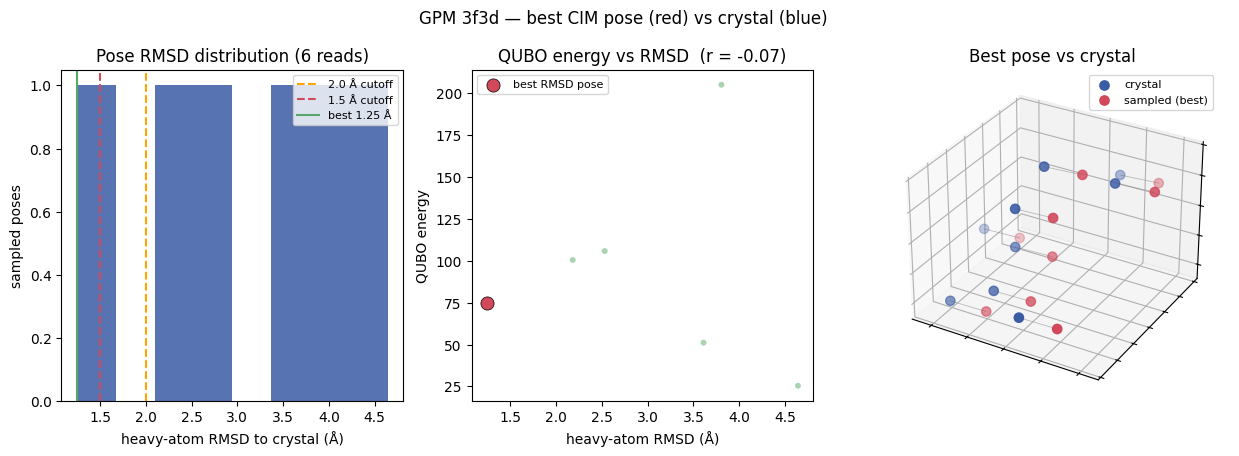

Vina: best pose 3.17  vs  crystal -6.62 kcal/mol


In [10]:
rmsd, energies, vina, P, bi = sweep[12]
fig = viz.summary_figure(rmsd, energies, P[bi], lig.coords, lig.elements,
                         suptitle='GPM 3f3d — best CIM pose (red) vs crystal (blue)')
plt.show()
vc = scoring.score_pose(g.receptor_pdbqt, lig.lines, lig.coords, 'nb_gpm/score', 'cryst')
print(f'Vina: best pose {vina[bi]:.2f}  vs  crystal {vc:.2f} kcal/mol')

## 4. FAM demo — 3d4z, read out as hydrogen bonds

3d4z is Golgi mannosidase II with **gluco-imidazole**, an iminosugar whose
recognition is all hydrogen bonds (2 N + 4 O). FAM rewards matching each ligand
atom to a pocket feature of similar electronegativity — i.e. polar atom to polar
feature — so it is the natural encoding for an H-bonded ligand. We cap the pocket
at **24 feature atoms** so the precision-expanded matrix stays under 1000 spins.

In [11]:
f = FAMDock(backend='cim', workdir='nb_fam', max_features=24)
f.make_receptor(f'{DATA}/3d4z_protein.pdb')
f.make_ligand([f'{DATA}/3d4z_ligand.mol2'])
f.make_box_ligand(f'{DATA}/3d4z_ligand.mol2')          # 1.0 Å (FAM default)
ligf = f.ligands[0]
Qf, vars_f = build_fam_qubo(ligf.coords, ligf.ad_types, f.feat_coords, f.feat_elements,
                            FAM_P['edge_cutoff'], FAM_P['K_dist'], FAM_P['K_mono'])
print('FAM QUBO variables:', Qf.shape[0], '| feature atoms:', len(f.feat_coords))

FAM QUBO variables: 336 | feature atoms: 24


Typed pocket feature atoms (N = blue, O = red) — a handful, vs hundreds of grid points:

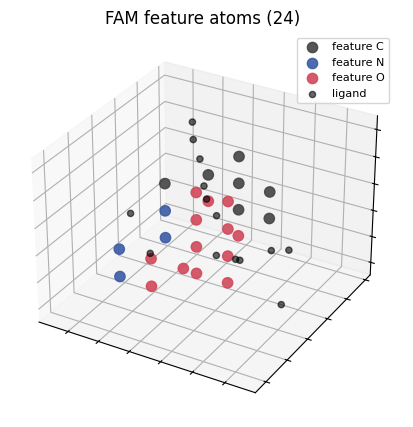

In [12]:
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_feature_sites(ax, f.feat_coords, f.feat_elements, ligf.coords); plt.show()

Same precision sweep on the CIM:

In [13]:
fsweep = {}
for t in (8, 10, 12):
    ranked = cim_dock(Qf, f'qdock_3d4z_FAM_1p0_p8t{t}', t)
    poses, energies = _matches_to_poses(ligf, np.array(vars_f), f.feat_coords, ranked)
    P, energies = np.array(poses), np.array(energies)
    rmsd = evaluate.pose_rmsds(P, ligf.coords, ligf.elements)
    vina = scoring.score_poses(f.receptor_pdbqt, ligf.lines, P, 'nb_fam/score')
    bi = int(np.nanargmin(vina))
    fsweep[t] = (rmsd, energies, vina, P, bi)
    print(f't={t:2d}  poses={len(P)}  mRMSD={rmsd.min():.2f}  vina-best RMSD={rmsd[bi]:.2f} Å')

[2026-06-23 02:42:48] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3d4z_FAM_1p0_p8t8


t= 8  poses=9  mRMSD=1.86  vina-best RMSD=3.48 Å


[2026-06-23 02:42:51] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3d4z_FAM_1p0_p8t10


t=10  poses=2  mRMSD=1.65  vina-best RMSD=1.65 Å


[2026-06-23 02:42:52] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: qdock_3d4z_FAM_1p0_p8t12


t=12  poses=8  mRMSD=1.84  vina-best RMSD=1.84 Å


**The hydrogen-bond read-out.** Take the best CIM pose and list every ligand N/O
that lands within 3.5 Å of a receptor N/O — these are the polar contacts the
encoding was built to find. The docked pose recovers the same hydrogen bonds as
the crystal:

In [14]:
def polar_contacts(xyz, el, rec_xyz, rec_el, cut=3.5):
    el = np.array([str(e).strip().upper()[:1] for e in el])
    rec_el = np.array([str(e).strip().upper()[:1] for e in rec_el])
    R = np.asarray(rec_xyz)[np.isin(rec_el, ['N','O'])]
    out = []
    for i in np.where(np.isin(el, ['N','O']))[0]:
        dmin = np.linalg.norm(R - xyz[i], axis=1).min()
        if dmin <= cut: out.append((el[i], i, round(float(dmin), 2)))
    return out

rmsd, energies, vina, P, bi = fsweep[12]
dock_hb  = polar_contacts(P[bi],       ligf.elements, f.rec_coords, f.rec_elements)
cryst_hb = polar_contacts(ligf.coords, ligf.elements, f.rec_coords, f.rec_elements)
print(f'docked pose ({rmsd[bi]:.2f} Å): {len(dock_hb)} polar contacts   |   crystal: {len(cryst_hb)}')
for el, i, d in dock_hb: print(f'  ligand {el}{i:<2d} → receptor polar atom  {d} Å')

docked pose (1.84 Å): 5 polar contacts   |   crystal: 5
  ligand N2  → receptor polar atom  3.28 Å
  ligand N8  → receptor polar atom  3.41 Å
  ligand O9  → receptor polar atom  2.55 Å
  ligand O10 → receptor polar atom  1.93 Å
  ligand O11 → receptor polar atom  2.56 Å


/Users/songxinwei/Downloads/qdock-kaiwu-workshop/qdock_kaiwu/viz.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


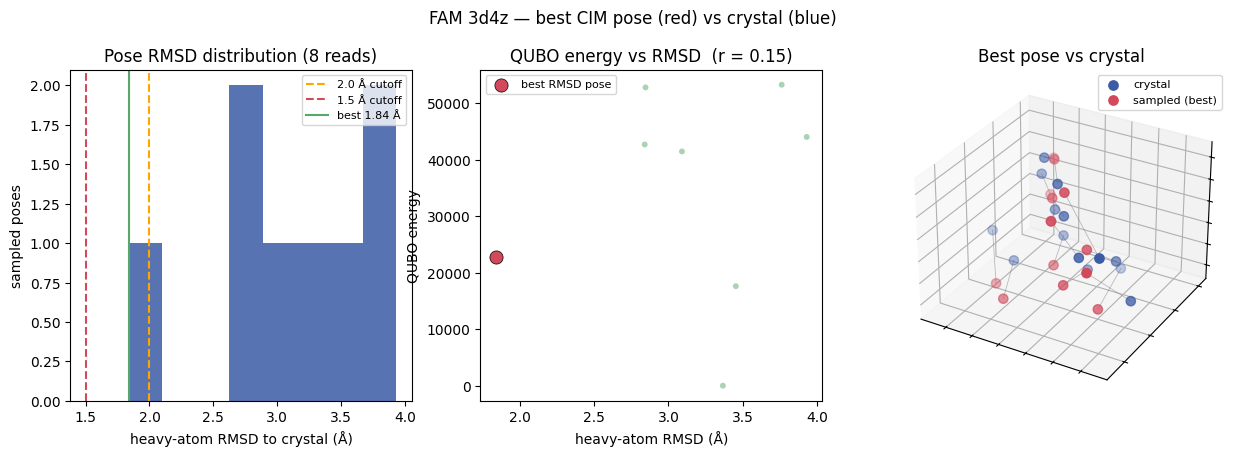

In [15]:
fig = viz.summary_figure(rmsd, energies, P[bi], ligf.coords, ligf.elements,
                         suptitle='FAM 3d4z — best CIM pose (red) vs crystal (blue)')
plt.show()

## 5. Takeaways

- Pose sampling → **QUBO** → `qubo_matrix_to_ising_matrix` → Kaiwu **SA** or the real **CIM**.
- The CIM is 8-bit: a `PrecisionReducer` quantizes the matrix, and `truncated_precision`
  trades **spins for reward precision**. On both demos the CIM docks **better as `t` rises** —
  until the expanded matrix would breach the ~1000-spin budget, which caps how far you push.
- Keep the QUBO small (few grid points / capped features) so the precision sweep fits the budget.
- **GPM** reads the pose as geometry (vdW grid); **FAM** reads it as chemistry — the docked
  pose's hydrogen bonds match the crystal's, atom for atom.